# Pre-stimulus block decodability vs LDA 1 (trial-count matched + pseudosession control)
Per session x region: decode block (0.2 vs 0.8) from the pre-stimulus window, **downsampled to a common trial count** across sessions (removes the trial-count confound). A **pseudosession null** (block re-generated with the same run-length structure, decoded from the *real* activity) controls for slow drift/autocorrelation. Corrected decodability = real - pseudo-mean, correlated with LDA 1.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os
from collections import defaultdict
from iblatlas.regions import BrainRegions
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score
from scipy.stats import pearsonr, spearmanr
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid'); plt.rcParams['figure.facecolor'] = 'white' 

In [ ]:
prefix = '/home/ines/repositories/representation_learning_variability/paper-individuality/'
firing_rates_dir = prefix + 'data/firing_rates/'
trials_path = prefix + '4_mice/all_trials_04-05-2026'
out_path = prefix + 'neural/decoding/decoding_block_pseudo_persession.parquet'
sweep_out_path = prefix + 'neural/decoding/decoding_block_pseudo_ncomp_sweep.parquet'

REGION_LEVEL = 'cosmos'
DROP = ['root', 'void']
PRESTIM_WIN = (-0.4, 0.0)
N_TARGET = 150            # common #(biased) trials per session
N_EVAL = 20              # PCA components (fixed a priori; sweep cell checks k-robustness)
N_PSEUDO = 100            # pseudosessions for the null (IBL generative, biased-only)
N_SUBSAMPLE_REPEATS = 10  # random trial subsamples averaged per region (stabilises against seed)
CV_FOLDS = 5
MIN_NEURONS = 10
MIN_SESSIONS_CORR = 15
SEED = 0
# IBL block generative params (biased blocks only; 0.5 opening is dropped from real data too)
BLK_MEAN = 60; BLK_MIN = 20; BLK_MAX = 100

trials_df = pd.read_parquet(trials_path)
# full block per session, chronological (still includes the 0.5 opening; dropped in the decode cell)
block_by_session = {s: g.sort_values('trial_id').set_index('trial_id')['block'] for s, g in trials_df.groupby('session')}
lda = pd.read_pickle(prefix + 'clustering/mouse_LDA_5_bins_cut19-06-2026').rename(columns={0: 'lda_1'})
br = BrainRegions()
print("params set (k=%d, N_PSEUDO=%d, %d subsample repeats)" % (N_EVAL, N_PSEUDO, N_SUBSAMPLE_REPEATS))

## Decoding + pseudosession helpers

In [ ]:
rng = np.random.default_rng(SEED)

def generate_pseudo_blocks(n_trials, rng):
    """IBL biased-block generative sequence, NO 0.5 opening (the neutral opening is excluded from
    the real data too). Alternating 0.2/0.8 blocks whose lengths ~ exponential(mean=60) truncated
    to [20,100]. Returns array in {0.2,0.8} of length n_trials."""
    out = []
    side = float(rng.choice([0.2, 0.8]))
    while len(out) < n_trials:
        x = rng.exponential(BLK_MEAN)
        while x < BLK_MIN or x > BLK_MAX:
            x = rng.exponential(BLK_MEAN)
        out += [side] * int(x)
        side = 0.8 if side == 0.2 else 0.2
    return np.array(out[:n_trials])

def make_folds(X, y_split, k, cv, seed):
    """Precompute scaler+PCA per CV fold once (folds fixed by y_split); reused across many label sets."""
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=seed)
    folds = []
    for tr, te in skf.split(X, y_split):
        sc = StandardScaler().fit(X[tr]); Xtr, Xte = sc.transform(X[tr]), sc.transform(X[te])
        nc = min(k, Xtr.shape[1], Xtr.shape[0] - 1)
        pca = PCA(n_components=nc, random_state=seed).fit(Xtr)
        folds.append((tr, te, pca.transform(Xtr), pca.transform(Xte)))
    return folds

def acc_labels(folds, y):
    """Balanced accuracy for a label vector using precomputed fold embeddings (only LDA refits)."""
    a = []
    for tr, te, Ztr, Zte in folds:
        if len(np.unique(y[tr])) < 2 or len(np.unique(y[te])) < 2: a.append(np.nan); continue
        a.append(balanced_accuracy_score(y[te], LDA().fit(Ztr, y[tr]).predict(Zte)))
    return np.nanmean(a)

## Load pre-stimulus activity

In [4]:
pkl_files = sorted([f for f in os.listdir(firing_rates_dir) if f.startswith('firing_rate_')])
with open(os.path.join(firing_rates_dir, pkl_files[0]), 'rb') as f:
    s0 = pickle.load(f)
tcols = sorted([c for c in s0.columns if c.startswith('t_')], key=lambda x: float(x.split('_')[1]))
tsec = np.array([float(c.split('_')[1]) for c in tcols])
pre_cols = [c for c, m in zip(tcols, (tsec >= PRESTIM_WIN[0]) & (tsec <= PRESTIM_WIN[1])) if m]

sess_pre = defaultdict(list)
for i, fn in enumerate(pkl_files):
    try:
        with open(os.path.join(firing_rates_dir, fn), 'rb') as f:
            d = pickle.load(f)
        d = d[~d['area'].isin(DROP)]
        if len(d) == 0: continue
        session = d['session'].iloc[0]
        d = d.copy(); d['nuid'] = d['pid'].astype(str) + '__' + d['neuron_id'].astype(str)
        d['pre'] = d[pre_cols].mean(axis=1)
        piv = d.pivot_table(index='trial_id', columns='nuid', values='pre')
        amap = d.groupby('nuid')['area'].first()
        if REGION_LEVEL == 'cosmos':
            cmap = dict(zip(amap.dropna().unique(), br.acronym2acronym(amap.dropna().unique(), mapping='Cosmos')))
            amap = amap.map(cmap)
        sess_pre[session].append((piv, amap))
        if (i + 1) % 100 == 0: print(f"  {i+1}/{len(pkl_files)} files...")
    except Exception as e:
        print(f"Error {fn}: {e}")
print(f"Sessions loaded: {len(sess_pre)}")

  100/380 files...
  200/380 files...
  300/380 files...
Sessions loaded: 244


## Decode real + pseudosessions (trial-count matched)

In [ ]:
records = []
for si, session in enumerate(sess_pre):
    X = pd.concat([p for p, _ in sess_pre[session]], axis=1)
    areas = pd.concat([a for _, a in sess_pre[session]]); areas = areas[~areas.index.duplicated()]
    blk = block_by_session.get(session)
    if blk is None: continue
    full = blk.values
    biased_pos_all = np.where(np.isin(full, [0.2, 0.8]))[0]         # contiguous biased span (0.5 opening dropped)
    if len(biased_pos_all) == 0: continue
    fb = biased_pos_all[0]                                          # first biased position (opening length)
    tids_all = blk.index.values[biased_pos_all]
    keep = np.isin(tids_all, X.index.values)                       # biased trials with neural data
    biased_pos = biased_pos_all[keep]; biased_tids = tids_all[keep]
    if len(biased_tids) < N_TARGET: continue
    real_seq = pd.Series(full[biased_pos]).map({0.2: 0, 0.8: 1}).values.astype(int)
    offsets = biased_pos - fb                                       # position within the biased span
    n_biased_all = len(biased_pos_all)
    # IBL pseudosessions over the biased span only (no 0.5) -> labels are always 0/1
    pseudos = []
    for _ in range(N_PSEUDO):
        pf = generate_pseudo_blocks(n_biased_all, rng)
        lab = pd.Series(pf[offsets]).map({0.2: 0, 0.8: 1}).values
        assert not np.isnan(lab).any(), "pseudo produced a non-biased label"
        pseudos.append(lab.astype(int))
    for region in pd.unique(areas.values):
        if region is None or (isinstance(region, float) and np.isnan(region)): continue
        cols = areas.index[areas.values == region]
        if len(cols) < MIN_NEURONS: continue
        Xr = X.loc[biased_tids, cols].values
        pos = np.where(~np.isnan(Xr).any(axis=1))[0]
        if len(pos) < N_TARGET: continue
        real_reps, pseudo_all = [], []                             # average real / pool null over repeats
        for _ in range(N_SUBSAMPLE_REPEATS):
            sub = rng.choice(pos, N_TARGET, replace=False)
            Xsub, y_real = Xr[sub], real_seq[sub]
            if len(np.unique(y_real)) < 2 or min(np.bincount(y_real)) < CV_FOLDS: continue
            folds = make_folds(Xsub, y_real, N_EVAL, CV_FOLDS, SEED)
            real_reps.append(acc_labels(folds, y_real))
            pseudo_all.extend(acc_labels(folds, ps[sub]) for ps in pseudos)
        if not real_reps: continue
        real = float(np.mean(real_reps))
        pm, psd = float(np.nanmean(pseudo_all)), float(np.nanstd(pseudo_all))
        records.append(dict(session=session, region=region, n_neurons=len(cols), n_trials=N_TARGET,
                            n_components=N_EVAL, n_repeats=len(real_reps),
                            real=real, pseudo_mean=pm, pseudo_std=psd,
                            corrected=real - pm, zscore=(real - pm) / (psd + 1e-9)))
    if (si + 1) % 40 == 0: print(f"  {si+1}/{len(sess_pre)} sessions...")

dec = pd.DataFrame(records)
dec.to_parquet(out_path)
print(f"Saved {len(dec)} entries (k={N_EVAL}, {N_SUBSAMPLE_REPEATS} repeats x {N_PSEUDO} pseudo) | "
      f"real mean={dec['real'].mean():.3f} pseudo mean={dec['pseudo_mean'].mean():.3f} "
      f"corrected mean={dec['corrected'].mean():.3f}")

## Correlate corrected block decodability with LDA 1 (+ plots)

In [ ]:
dec = pd.read_parquet(out_path)   # reload from disk -> this + plot cell reproduce everything in seconds
p = dec.merge(lda[['session', 'lda_1', 'mouse_name']], on='session').dropna(subset=['lda_1'])
well = p.groupby('region')['session'].nunique(); well = well[well >= MIN_SESSIONS_CORR].index.tolist()
p = p[p.region.isin(well)]
print(f"n={len(p)} session-region entries (k={dec['n_components'].iloc[0]}); well-sampled regions: {well}\n")
for metric in ['real', 'corrected', 'zscore']:
    print(f"---- {metric} vs LDA 1 ----")
    for reg, g in p.groupby('region'):
        r, pv = pearsonr(g['lda_1'], g[metric]); rho, pvv = spearmanr(g['lda_1'], g[metric])
        print(f"  {reg:10s} n={len(g):3d}: r={r:+.2f} p={pv:.3f} | rho={rho:+.2f} p={pvv:.3f}")
    try:
        mm = smf.mixedlm(f"{metric} ~ lda_1 + C(region) + n_neurons", p, groups=p['mouse_name'],
                         vc_formula={'session': '0 + C(session)'}).fit(reml=True); ml = 'mouse+session'
    except Exception:
        mm = smf.mixedlm(f"{metric} ~ lda_1 + C(region) + n_neurons", p, groups=p['session']).fit(reml=True); ml = 'session'
    b, se, pv = mm.params['lda_1'], mm.bse['lda_1'], mm.pvalues['lda_1']
    print(f"  POOLED {metric} ~ lda_1 + C(region) + n_neurons + (1|mouse) [{ml}]: coef={b:+.4f} z={b/se:+.2f} p={pv:.4f}\n")

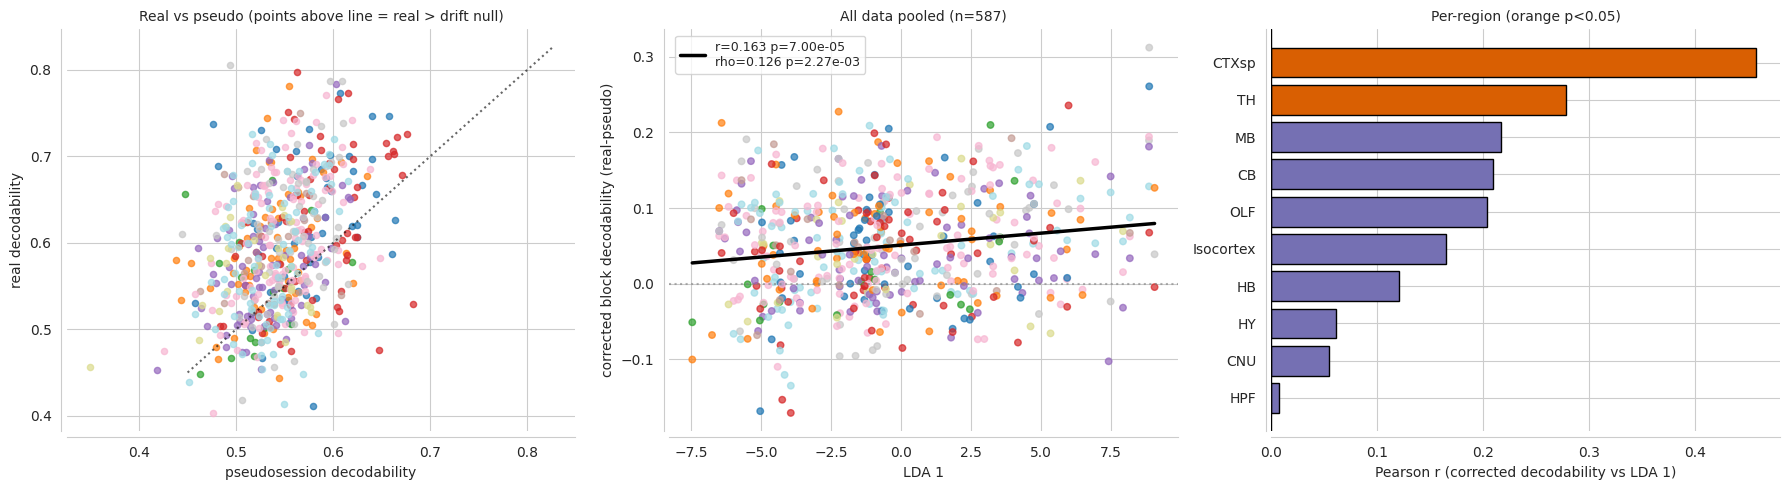

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
region_list = sorted(p['region'].unique())
pal = dict(zip(region_list, plt.cm.tab20(np.linspace(0, 1, len(region_list)))))
# (1) real vs pseudo levels
for reg in region_list:
    g = p[p.region == reg]; axes[0].scatter(g['pseudo_mean'], g['real'], color=pal[reg], s=20, alpha=0.7)
lims = [0.45, max(p['real'].max(), p['pseudo_mean'].max()) + 0.02]
axes[0].plot(lims, lims, 'k:', alpha=0.6); axes[0].set_xlabel('pseudosession decodability'); axes[0].set_ylabel('real decodability')
axes[0].set_title('Real vs pseudo (points above line = real > drift null)', fontsize=10); sns.despine(ax=axes[0], offset=5)
# (2) corrected vs LDA1, all data pooled
x = p['lda_1'].values; y = p['corrected'].values
r, pv = pearsonr(x, y); rho, pvv = spearmanr(x, y)
axes[1].scatter(x, y, c=[pal[rr] for rr in p['region']], s=22, alpha=0.7)
z = np.polyfit(x, y, 1); xl = np.linspace(x.min(), x.max(), 100)
axes[1].plot(xl, np.polyval(z, xl), 'k-', lw=2.5, label=f'r={r:.3f} p={pv:.2e}\nrho={rho:.3f} p={pvv:.2e}')
axes[1].axhline(0, color='gray', ls=':', alpha=0.6)
axes[1].set_xlabel('LDA 1'); axes[1].set_ylabel('corrected block decodability (real-pseudo)')
axes[1].set_title(f'All data pooled (n={len(p)})', fontsize=10); axes[1].legend(fontsize=9)
# (3) per-region r bar
rs = sorted([(reg, pearsonr(g['lda_1'], g['corrected'])[0], pearsonr(g['lda_1'], g['corrected'])[1])
             for reg, g in p.groupby('region')], key=lambda t: t[1])
cols = ['#d95f02' if pp < 0.05 else '#7570b3' for _, _, pp in rs]
axes[2].barh([t[0] for t in rs], [t[1] for t in rs], color=cols, edgecolor='black'); axes[2].axvline(0, color='black', lw=1)
axes[2].set_xlabel('Pearson r (corrected decodability vs LDA 1)'); axes[2].set_title('Per-region (orange p<0.05)', fontsize=10)
for ax in axes: sns.despine(ax=ax, offset=4)
plt.tight_layout(); plt.show()

## Robustness: does the LDA 1 correlation depend on the number of PCA components?
Lighter diagnostic (fewer repeats / pseudosessions) sweeping k. PCA components are nested, so we fit
PCA once per fold at `K_MAX` and slice the first k columns. We report the pooled mixed-model p at each
k so k=20 is seen in context (not cherry-picked). Absent at k<=3, appears at k=5, most stable at k>=15.

In [ ]:
K_MAX = 30; KS = [1, 2, 3, 5, 8, 10, 15, 20, 30]; SW_REPEATS = 3; SW_PSEUDO = 50
rng_sw = np.random.default_rng(SEED)

def folds_kmax(X, y_split):
    skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED); out = []
    for tr, te in skf.split(X, y_split):
        sc = StandardScaler().fit(X[tr]); Xtr, Xte = sc.transform(X[tr]), sc.transform(X[te])
        nc = min(K_MAX, Xtr.shape[1], Xtr.shape[0] - 1)
        pca = PCA(n_components=nc, random_state=SEED).fit(Xtr)
        out.append((tr, te, pca.transform(Xtr), pca.transform(Xte)))
    return out

def acc_k(folds, y, k):
    a = []
    for tr, te, Ztr, Zte in folds:
        kk = min(k, Ztr.shape[1])
        if len(np.unique(y[tr])) < 2 or len(np.unique(y[te])) < 2: a.append(np.nan); continue
        a.append(balanced_accuracy_score(y[te], LDA().fit(Ztr[:, :kk], y[tr]).predict(Zte[:, :kk])))
    return np.nanmean(a)

sw = []
for session in sess_pre:
    X = pd.concat([p for p, _ in sess_pre[session]], axis=1)
    areas = pd.concat([a for _, a in sess_pre[session]]); areas = areas[~areas.index.duplicated()]
    blk = block_by_session.get(session)
    if blk is None: continue
    full = blk.values; bpa = np.where(np.isin(full, [0.2, 0.8]))[0]
    if len(bpa) == 0: continue
    fb = bpa[0]; tids_all = blk.index.values[bpa]; keep = np.isin(tids_all, X.index.values)
    biased_pos = bpa[keep]; biased_tids = tids_all[keep]
    if len(biased_tids) < N_TARGET: continue
    real_seq = pd.Series(full[biased_pos]).map({0.2: 0, 0.8: 1}).values.astype(int)
    offsets = biased_pos - fb; n_bias = len(bpa)
    pseudos = []
    for _ in range(SW_PSEUDO):
        pf = generate_pseudo_blocks(n_bias, rng_sw)
        pseudos.append(pd.Series(pf[offsets]).map({0.2: 0, 0.8: 1}).values.astype(int))
    for region in pd.unique(areas.values):
        if region is None or (isinstance(region, float) and np.isnan(region)): continue
        cols = areas.index[areas.values == region]
        if len(cols) < MIN_NEURONS: continue
        Xr = X.loc[biased_tids, cols].values; pos = np.where(~np.isnan(Xr).any(axis=1))[0]
        if len(pos) < N_TARGET: continue
        acc = {k: {'r': [], 'c': []} for k in KS}
        for _ in range(SW_REPEATS):
            sub = rng_sw.choice(pos, N_TARGET, replace=False); Xsub, y_real = Xr[sub], real_seq[sub]
            if len(np.unique(y_real)) < 2 or min(np.bincount(y_real)) < CV_FOLDS: continue
            folds = folds_kmax(Xsub, y_real)
            for k in KS:
                rk = acc_k(folds, y_real, k); pm = np.nanmean([acc_k(folds, ps[sub], k) for ps in pseudos])
                acc[k]['r'].append(rk); acc[k]['c'].append(rk - pm)
        if not acc[KS[0]]['r']: continue
        rec = dict(session=session, region=region, n_neurons=len(cols))
        for k in KS:
            rec[f'real_{k}'] = np.mean(acc[k]['r']); rec[f'corr_{k}'] = np.mean(acc[k]['c'])
        sw.append(rec)

sw_raw = pd.DataFrame(sw)
sw_raw.to_parquet(sweep_out_path)                 # saved -> re-run the table below from disk without redoing the sweep
sw = sw_raw.merge(lda[['session', 'lda_1', 'mouse_name']], on='session').dropna(subset=['lda_1'])
sw = sw[sw.region.isin(well)]
print(f"sweep saved: {len(sw_raw)} entries ({SW_REPEATS} repeats x {SW_PSEUDO} pseudo) -> {sweep_out_path}")
print(f"used in table: n={len(sw)}\n")
print(f"{'k':>4} | {'real p':>8} {'real z':>7} | {'corr p':>8} {'corr z':>7} | {'mean real':>9} {'mean corr':>9}")
for k in KS:
    line = f"{k:>4} |"
    for m in [f'real_{k}', f'corr_{k}']:
        try:
            mm = smf.mixedlm(f"{m} ~ lda_1 + C(region) + n_neurons", sw, groups=sw['mouse_name'],
                             vc_formula={'session': '0 + C(session)'}).fit(reml=True)
        except Exception:
            mm = smf.mixedlm(f"{m} ~ lda_1 + C(region) + n_neurons", sw, groups=sw['session']).fit(reml=True)
        b, se, pv = mm.params['lda_1'], mm.bse['lda_1'], mm.pvalues['lda_1']
        line += f" {pv:>8.4f} {b/se:>7.2f} |"
    line += f" {sw[f'real_{k}'].mean():>9.3f} {sw[f'corr_{k}'].mean():>9.3f}"
    print(line + ("   <- locked k" if k == N_EVAL else ""))